In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from xgboost import XGBClassifier

df = pd.read_csv("cs-training.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [80]:
print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
df.describe()

Number of rows and columns:
(150000, 12)

Column names:
['Unnamed: 0', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                        

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [81]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


In [82]:
# Remove unnecessary column if it exists
df = df.drop("Unnamed: 0", axis=1, errors="ignore")

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing values with median
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(
    df["MonthlyIncome"].median()
)

df["NumberOfDependents"] = df["NumberOfDependents"].fillna(
    df["NumberOfDependents"].median()
)

print("Missing values after preprocessing:")
print(df.isnull().sum())

print("\nDataset shape after cleaning:")
print(df.shape)

Missing values after preprocessing:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

Dataset shape after cleaning:
(149391, 11)


Target variable distribution:
SeriousDlqin2yrs
0    139382
1     10009
Name: count, dtype: int64


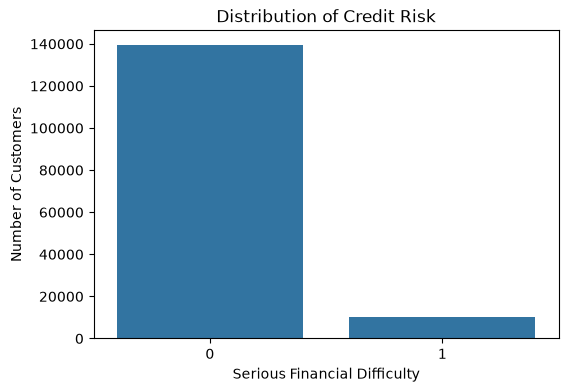

In [83]:
print("Target variable distribution:")
print(df["SeriousDlqin2yrs"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x="SeriousDlqin2yrs", data=df)
plt.title("Distribution of Credit Risk")
plt.xlabel("Serious Financial Difficulty")
plt.ylabel("Number of Customers")
plt.show()

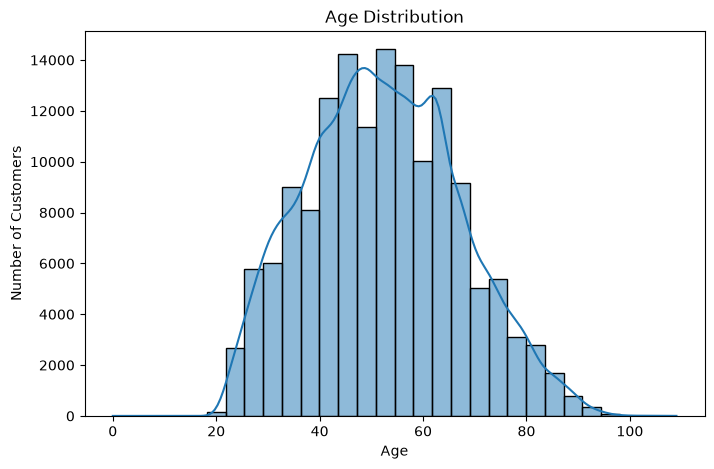

In [84]:
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

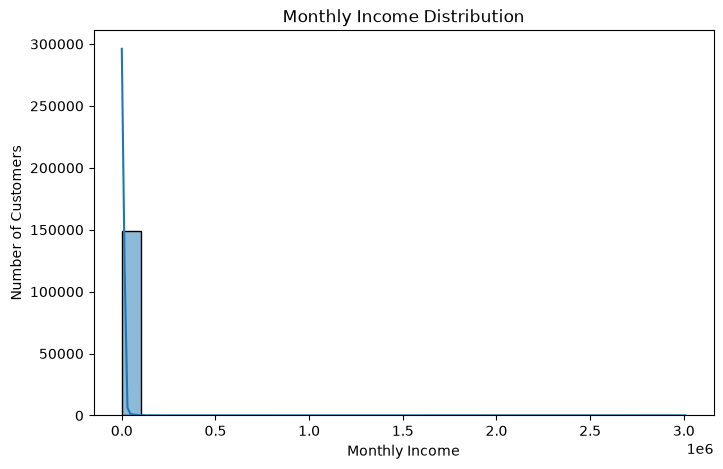

In [85]:
plt.figure(figsize=(8, 5))
sns.histplot(df["MonthlyIncome"], bins=30, kde=True)
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Customers")
plt.show()

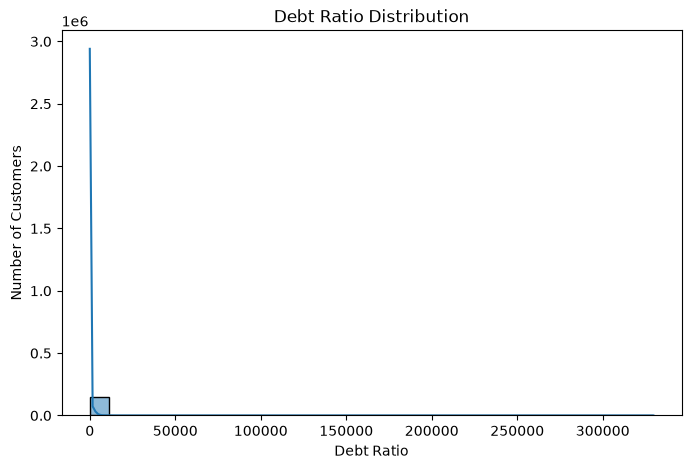

In [86]:
plt.figure(figsize=(8, 5))
sns.histplot(df["DebtRatio"], bins=30, kde=True)
plt.title("Debt Ratio Distribution")
plt.xlabel("Debt Ratio")
plt.ylabel("Number of Customers")
plt.show()

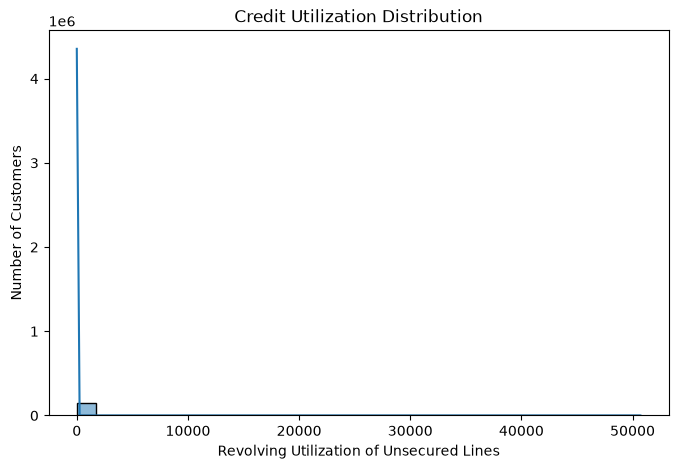

In [87]:
plt.figure(figsize=(8, 5))
sns.histplot(
    df["RevolvingUtilizationOfUnsecuredLines"],
    bins=30,
    kde=True
)

plt.title("Credit Utilization Distribution")
plt.xlabel("Revolving Utilization of Unsecured Lines")
plt.ylabel("Number of Customers")
plt.show()

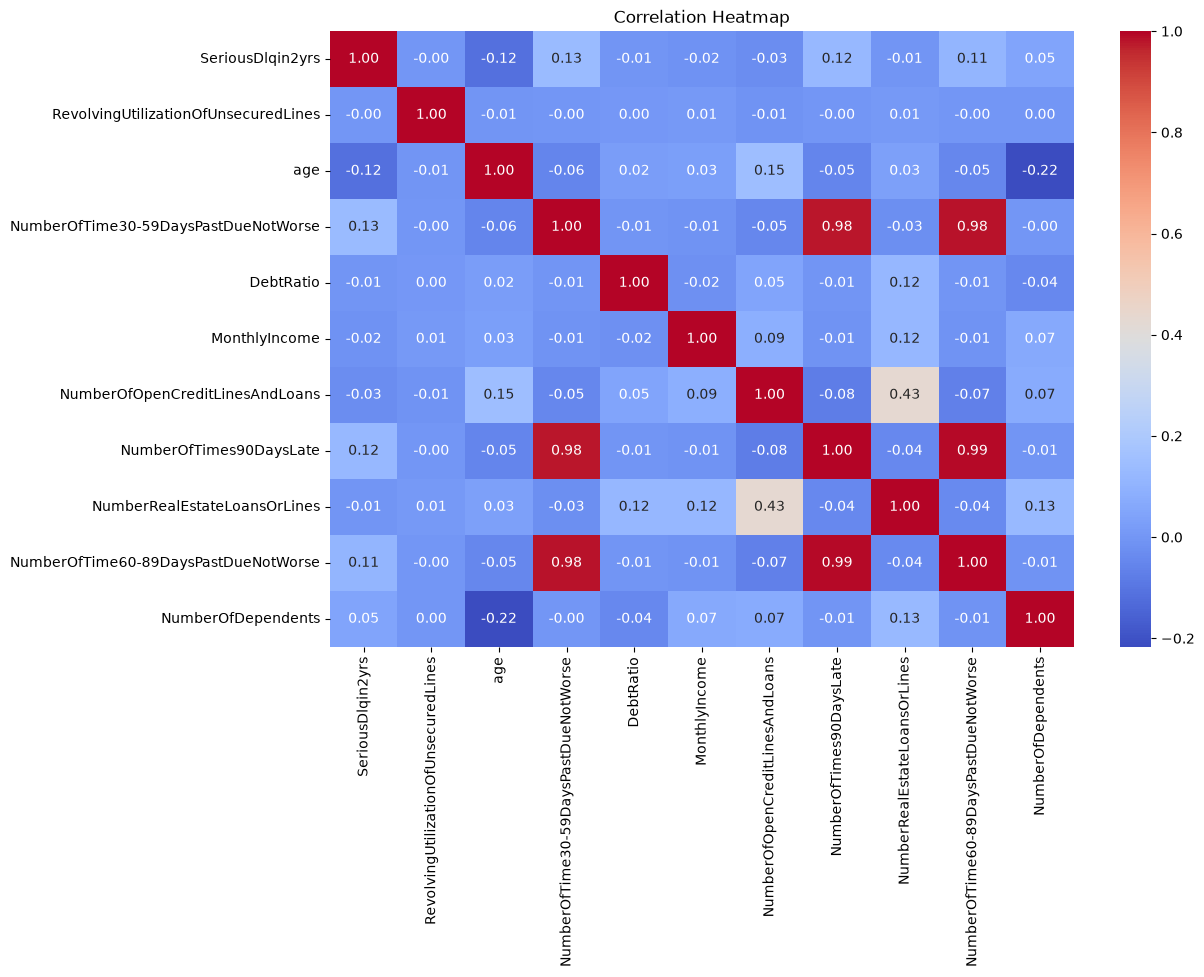

In [88]:
plt.figure(figsize=(12, 8))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [89]:
X = df.drop("SeriousDlqin2yrs", axis=1)
y = df["SeriousDlqin2yrs"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("SeriousDlqin2yrs")

Features:
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Target:
SeriousDlqin2yrs


In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (119512, 10)
Testing data: (29879, 10)


In [91]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [92]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [93]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

y_prob_logistic = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Logistic Regression predictions completed.")

Logistic Regression predictions completed.


In [94]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1-Score :", logistic_f1)
print("ROC-AUC  :", logistic_roc_auc)

Logistic Regression Results
--------------------------------
Accuracy : 0.9331302921784531
Precision: 0.512987012987013
Recall   : 0.039460539460539464
F1-Score : 0.07328385899814471
ROC-AUC  : 0.6990282021311186


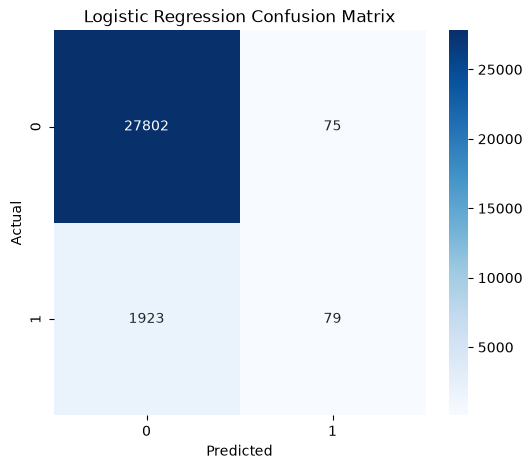

In [95]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [96]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [97]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:, 1]

print("XGBoost predictions completed.")

XGBoost predictions completed.


In [98]:
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("XGBoost Results")
print("--------------------------------")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1-Score :", xgb_f1)
print("ROC-AUC  :", xgb_roc_auc)

XGBoost Results
--------------------------------
Accuracy : 0.9374142374242779
Precision: 0.5948275862068966
Recall   : 0.20679320679320679
F1-Score : 0.30689399555226093
ROC-AUC  : 0.8650356262097123


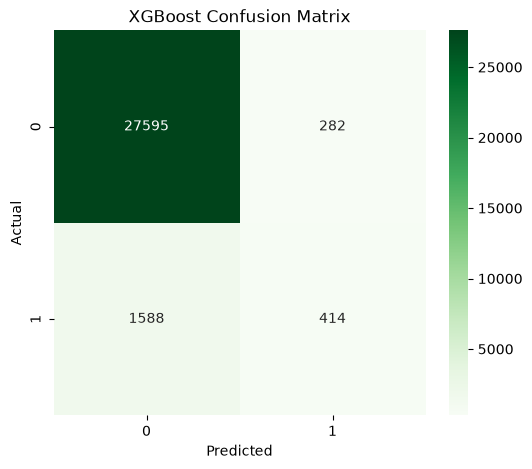

In [99]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [100]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    "Logistic Regression": [
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1,
        logistic_roc_auc
    ],

    "XGBoost": [
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1,
        xgb_roc_auc
    ]
})

results

,Metric,Logistic Regression,XGBoost
0,Accuracy,0.933130,0.937414
1,Precision,0.512987,0.594828
2,Recall,0.039461,0.206793
3,F1-Score,0.073284,0.306894
4,ROC-AUC,0.699028,0.865036


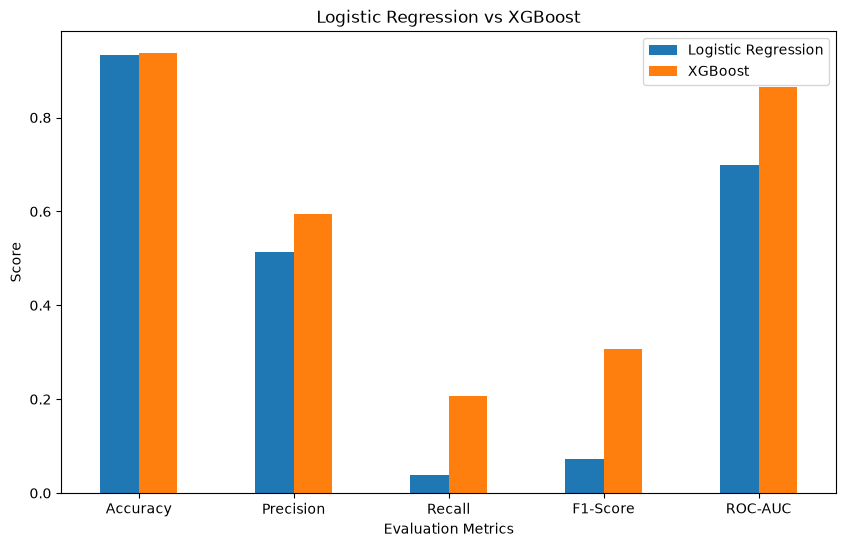

In [101]:
results_plot = results.set_index("Metric")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Logistic Regression vs XGBoost")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()
plt.show()

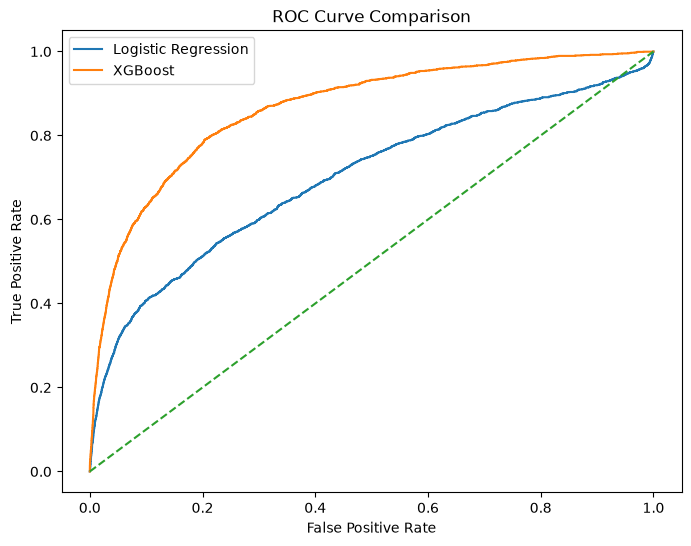

In [102]:
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label="Logistic Regression"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

                                Feature  Importance
6               NumberOfTimes90DaysLate    0.394818
0  RevolvingUtilizationOfUnsecuredLines    0.213262
2  NumberOfTime30-59DaysPastDueNotWorse    0.168016
8  NumberOfTime60-89DaysPastDueNotWorse    0.112834
1                                   age    0.025401
7          NumberRealEstateLoansOrLines    0.024577
5       NumberOfOpenCreditLinesAndLoans    0.018422
3                             DebtRatio    0.016409
4                         MonthlyIncome    0.014510
9                    NumberOfDependents    0.011752


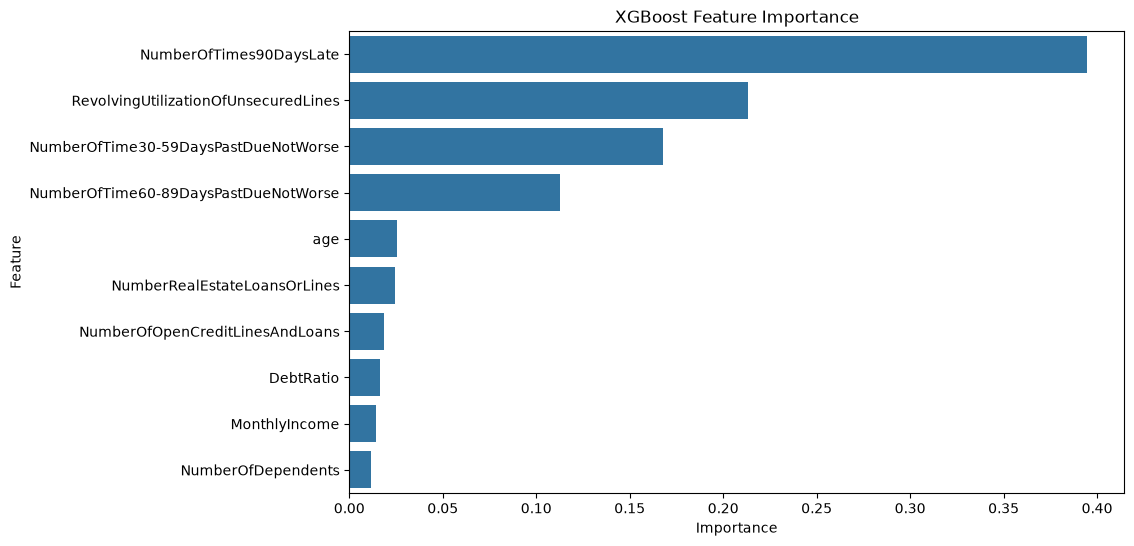

In [103]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
print("PROJECT SUMMARY")
print("=" * 50)

print("\nModels Used:")
print("1. Logistic Regression")
print("2. XGBoost")

print("\nEvaluation Metrics:")
print("1. Accuracy")
print("2. Precision")
print("3. Recall")
print("4. F1-Score")
print("5. ROC-AUC")

print("\nLogistic Regression:")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1-Score :", round(logistic_f1, 4))
print("ROC-AUC  :", round(logistic_roc_auc, 4))

print("\nXGBoost:")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1-Score :", round(xgb_f1, 4))
print("ROC-AUC  :", round(xgb_roc_auc, 4))

PROJECT SUMMARY

Models Used:
1. Logistic Regression
2. XGBoost

Evaluation Metrics:
1. Accuracy
2. Precision
3. Recall
4. F1-Score
5. ROC-AUC

Logistic Regression:
Accuracy : 0.9331
Precision: 0.513
Recall   : 0.0395
F1-Score : 0.0733
ROC-AUC  : 0.699

XGBoost:
Accuracy : 0.9374
Precision: 0.5948
Recall   : 0.2068
F1-Score : 0.3069
ROC-AUC  : 0.865


: 